In [1]:
# Stage 1: Import Libraries
# Importing the required libraries for data analysis, visualization, and machine learning

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Stage 2: Load Dataset
# Loading the breast cancer dataset.

In [4]:
df = pd.read_csv("data.csv")

In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
df.shape

(569, 33)

In [8]:
# Stage 3: Data Cleaning
# Removing unnecessary columns that won't help in prediction.

In [9]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [10]:
df.drop(
    ['id', 'Unnamed: 32'],
    axis=1,
    inplace=True
)

In [11]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
# Stage 4: Diagnosis Analysis
# Checking the distribution of malignant and benign tumor cases.

In [13]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

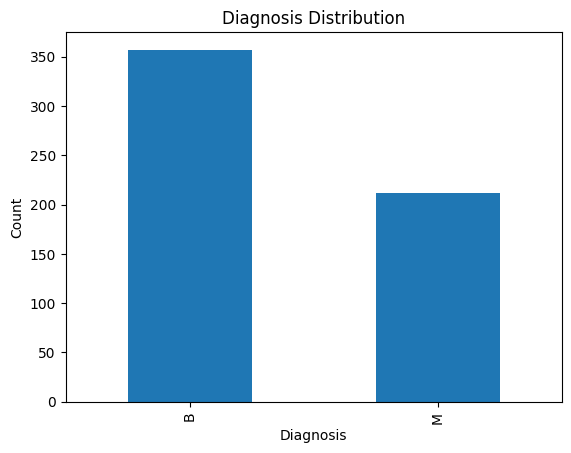

In [14]:
df['diagnosis'].value_counts().plot(kind='bar')

plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

In [15]:
# Stage 5: Convert Target Variable
# Converting diagnosis labels into numerical values for machine learning models.

In [16]:
df['diagnosis'] = df['diagnosis'].map({
    'M': 1,
    'B': 0
})

In [17]:
df['diagnosis'].head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [18]:
# Stage 6: Feature Selection
# Separating input features and target variable.

In [19]:
X = df.drop(
    'diagnosis',
    axis=1
)

y = df['diagnosis']

In [20]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [21]:
# Stage 7: Train-Test Split
# Splitting the dataset into training and testing sets.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
# Stage 8: Logistic Regression
# Training a Logistic Regression model to classify tumors.

In [24]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Accuracy:", accuracy_lr)

Accuracy: 0.956140350877193


In [25]:
# Stage 9: KNN Classifier
# Training a KNN model and checking its accuracy.

In [26]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print("Accuracy:", accuracy_knn)

Accuracy: 0.956140350877193


In [27]:
# Stage 10: Decision Tree Classifier
# Training a Decision Tree model for classification.

In [28]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

print("Accuracy:", accuracy_dt)

Accuracy: 0.9473684210526315


In [29]:
# Stage 11: Random Forest Classifier
# Training a Random Forest model and evaluating its performance.

In [30]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Accuracy:", accuracy_rf)

Accuracy: 0.9649122807017544


In [31]:
# Stage 12: Model Comparison
# Comparing the accuracy of all models.

In [32]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.956140
1,KNN,0.956140
2,Decision Tree,0.947368
3,Random Forest,0.964912


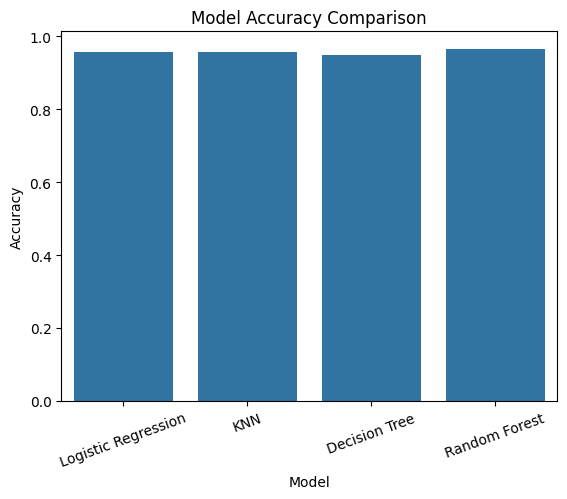

In [33]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.xticks(rotation=20)

plt.title("Model Accuracy Comparison")

plt.show()

In [34]:
# Stage 13: Best Model Evaluation
# Evaluating the best-performing model using a confusion matrix and classification report.

In [35]:
print(
    confusion_matrix(
        y_test,
        y_pred_rf
    )
)

[[70  1]
 [ 3 40]]


In [36]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [37]:
# Key Findings
# 1. The dataset contained 569 breast cancer records, with 357 benign tumors and 212 malignant tumors. This shows that benign cases were more common in the dataset.
# 2. Logistic Regression and KNN both achieved an accuracy of 95.61%, showing strong performance in classifying tumors.
# 3. Decision Tree achieved an accuracy of 94.74%, which was slightly lower than the other models.
# 4. Random Forest achieved the highest accuracy of 96.49%, making it the best-performing model in this analysis.
# 5. The confusion matrix showed that the Random Forest model correctly classified most tumor cases, with only 4 misclassifications out of 114 test samples.
# 6. The classification report showed high precision, recall, and F1-scores for both benign and malignant classes, indicating reliable prediction performance.